# Raman mineral identification: multiclass selection on a real archive

180 processed Raman spectra from the RRUFF archive (excellent unoriented
set): six minerals (grossular, diamond, epidote, andradite, beryl,
calcite), 80 physical specimens, four laser configurations, binned onto a
common 150 to 1400 inverse cm grid. Two properties make this the honest
multiclass example:

- the per-spectrum wavenumber ranges genuinely differ (some spectra
  observe only 74% of the grid), so the validity mask carries REAL
  missingness, not an imposed scenario;
- several spectra share a physical specimen, so grouped CV is mandatory.

And, as measured below, the MNAR guard fires on this real archive: WHICH
range an instrument covered is correlated with WHAT mineral was measured.
That is an archive-composition confound the analysis must carry, and it is
precisely the kind of thing imputation-first pipelines never get to see.

In [1]:
import sys
sys.path.insert(0, "../benchmarks")
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_rruff

X, V, y, meta = load_rruff()
classes = meta["classes"]
wavenumber = np.linspace(150, 1400, X.shape[-1])
specimens = np.unique(meta["groups"], return_inverse=True)[1]
print(X.shape, "classes:", classes)
print("per class:", np.bincount(y).tolist(), " specimens:", len(set(specimens)))
print("observed fraction per spectrum: min",
      round(float(V[:, 0].mean(axis=1).min()), 2))

(180, 1, 512) classes: ['Grossular', 'Diamond', 'Epidote', 'Andradite', 'Beryl', 'Calcite']
per class: [42, 30, 29, 27, 26, 26]  specimens: 80
observed fraction per spectrum: min 0.74


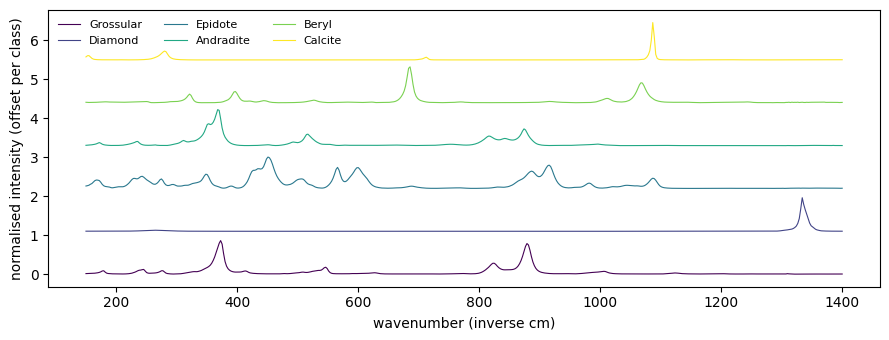

In [2]:
# class-mean spectra over their observed ranges (viridis by class)
fig, ax = plt.subplots(figsize=(9, 3.5))
for k, name in enumerate(classes):
    rows = y == k
    num = (X[rows, 0] * V[rows, 0]).sum(axis=0)
    den = V[rows, 0].sum(axis=0)
    mean = np.divide(num, den, out=np.zeros_like(num), where=den > 0)
    ax.plot(wavenumber, mean + 1.1 * k, lw=0.8,
            color=plt.cm.viridis(k / (len(classes) - 1)), label=name)
ax.set_xlabel("wavenumber (inverse cm)")
ax.set_ylabel("normalised intensity (offset per class)")
ax.legend(frameon=False, ncol=3, fontsize=8)
plt.tight_layout()

## Which bands identify the minerals

Multiclass stability selection at an eight-band budget (roughly 20 inverse
cm per segment). The known Raman fingerprints are the test: diamond's
single line at 1332, calcite's carbonate stretch at 1086, beryl near 1067
and 686, the garnet and epidote bands below about 1030.

In [3]:
from robustsignalmaker import BootstrapMaskSelector

sel = BootstrapMaskSelector(task="multiclass", segment=8, lam=0.08,
                            n_iter=300, lr=0.1, n_bootstrap=25,
                            target_coverage=8 / 64, seed=0).fit(X, y, V)
for s in sel.selected_segments_:
    pts = sel.grid.segments_to_points([s])
    print(f"{wavenumber[pts[0]]:.0f} to {wavenumber[pts[-1]]:.0f} cm-1  "
          f"pi={sel.pi_[s]:.2f}  support={sel.support_[s]:.2f}")

307 to 324 cm-1  pi=0.56  support=1.00
365 to 382 cm-1  pi=0.52  support=1.00
502 to 519 cm-1  pi=0.96  support=1.00
698 to 715 cm-1  pi=0.36  support=1.00
991 to 1009 cm-1  pi=0.92  support=1.00
1011 to 1028 cm-1  pi=0.36  support=1.00
1070 to 1087 cm-1  pi=0.84  support=1.00
1324 to 1341 cm-1  pi=0.96  support=1.00


In [4]:
# eight bands versus the whole spectrum, uniform multiclass scorer.
# HONESTY NOTES on this quick comparison: the bands were selected using ALL
# labels, so these CV numbers are optimistic for the selection (the grouped
# nested run below is the claimable one), and the features are
# validity-weighted segment means so unobserved bins are absent, not zeros
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from robustsignalmaker import SegmentGrid, SegmentMean

def mc_scores(F, yv, seed=0):
    model = make_pipeline(StandardScaler(),
                          LogisticRegression(max_iter=2000, random_state=seed))
    cv = StratifiedKFold(5, shuffle=True, random_state=seed)
    proba = cross_val_predict(model, F, yv, cv=cv, method="predict_proba")
    return (roc_auc_score(yv, proba, multi_class="ovr", average="weighted"),
            accuracy_score(yv, proba.argmax(1)))

grid = SegmentGrid(512, segment=8)
F_seg, _ = SegmentMean().transform(X, V.astype(float), grid)
F_seg = F_seg[:, :, 0]
auc_sel, acc_sel = mc_scores(F_seg[:, sel.selected_segments_], y)
auc_full, acc_full = mc_scores(F_seg, y)
print(f"eight bands: AUC-OVR {auc_sel:.3f}, accuracy {acc_sel:.3f}")
print(f"full grid:   AUC-OVR {auc_full:.3f}, accuracy {acc_full:.3f}")

eight bands: AUC-OVR 0.999, accuracy 0.972
full grid:   AUC-OVR 0.989, accuracy 0.950


Measured: the eight bands land on the textbook fingerprints (1324 to 1341
covering diamond's 1332; 1070 to 1087 covering calcite's 1086, with
beryl's 1067 in the adjacent segment; 991 to 1028 for the epidote and
andradite region; the 300 to 520 garnet bands), and the quick comparison
above suggests selection loses nothing to the full grid despite an
eight-fold compression. The number that can be QUOTED is the grouped
nested run below (selection refitted inside every training fold, specimens
never split): AUC 0.9947 for the selected bands against 0.9935 for the
full spectrum, verdict `preserved`.

## The archive confound: a real MNAR alarm

The honest generalisation run below stratifies by SPECIMEN (grouped CV: a
physical crystal never spans a train/test split) and runs the MNAR guard
per fold. On this real archive the guard FIRES: the coverage pattern alone
predicts the mineral (permutation p about 0.02), pointing at the top of
the range (1300 to 1400 inverse cm), where some instrument configurations
stop early. Read that carefully: diamond's own diagnostic band sits in
exactly that region, so part of "diamond-ness" could in principle be
encoded by WHICH instrument measured the specimen rather than by the
physics. The verdict stays honest because the warning is stamped into the
result; a pipeline that imputed or zero-filled the uncovered ranges would
have deleted the evidence that this question needed asking.

In [5]:
from robustsignalmaker import NestedCV

res = NestedCV(k_outer=4, segment=8, lam=0.08, n_bootstrap=15,
               target_coverage=8 / 64, mnar_permutations=40,
               random_state=0).run(X, y, V, groups=specimens)
s = res.summary()
{k: s[k] for k in ("score_name", "score_mean", "baseline_score_mean",
                    "verdict", "selection_stability_adjusted",
                    "mean_n_selected", "missingness_informative", "grouped")}

C:\Users\Amanda\Favorites\Machine Learning\RobustSignalMaker\robustsignalmaker\nested_cv.py:404: MissingnessInformativeWarning: missingness pattern alone predicts the target (score=0.624, permutation p=0.0244; most associated segments: [63, 62, 61, 60, 59]); observed-data selection is confounded with the observation process
  mnar = missingness_association(


C:\Users\Amanda\Favorites\Machine Learning\RobustSignalMaker\robustsignalmaker\nested_cv.py:404: MissingnessInformativeWarning: missingness pattern alone predicts the target (score=0.627, permutation p=0.0244; most associated segments: [63, 62, 61, 60, 59]); observed-data selection is confounded with the observation process
  mnar = missingness_association(


C:\Users\Amanda\Favorites\Machine Learning\RobustSignalMaker\robustsignalmaker\nested_cv.py:404: MissingnessInformativeWarning: missingness pattern alone predicts the target (score=0.662, permutation p=0.0244; most associated segments: [63, 62, 61, 60, 59]); observed-data selection is confounded with the observation process
  mnar = missingness_association(


C:\Users\Amanda\AppData\Roaming\Python\Python39\site-packages\scipy\stats\_wilcoxon.py:199: UserWarning: Sample size too small for normal approximation.
  temp = _wilcoxon_iv(x, y, zero_method, correction, alternative, method, axis)


{'score_name': 'AUC-OVR',
 'score_mean': 0.9946675297488163,
 'baseline_score_mean': 0.9935397902604804,
 'verdict': 'preserved',
 'selection_stability_adjusted': 0.5186455963998337,
 'mean_n_selected': 8.5,
 'missingness_informative': True,
 'grouped': True}

In [6]:
informative = [r for r in res.mnar_reports if r["verdict"] == "informative"]
print(f"MNAR guard fired in {len(informative)} of {len(res.mnar_reports)} folds")
if informative:
    segs = informative[0]["top_segments"]
    print("most target-associated coverage segments:",
          [f"{wavenumber[s * 8]:.0f} cm-1" for s in segs])

MNAR guard fired in 3 of 4 folds
most target-associated coverage segments: ['1383 cm-1', '1363 cm-1', '1344 cm-1', '1324 cm-1', '1305 cm-1']


## What to report

Eight bands (8.5 on average across folds) identify six minerals at
AUC 0.995 under specimen-grouped
nested CV, verdict `preserved` against the full spectrum; the bands are
the textbook fingerprints; and the report must carry the archive
confound: coverage correlates with class, so any claim about bands in the
1300 to 1400 region should be re-checked on spectra whose ranges all
include it (the support maps say exactly which those are). Template:
INTERPRETATION_GUIDE section 11.